<a href="https://colab.research.google.com/github/akhilesh0405/vendingmachine1/blob/main/image_classification_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [5]:
dataset_path = "/content/drive/MyDrive/ML_Assignment/seg_train"


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)


In [6]:
import os
os.listdir(dataset_path)


['mountain', 'glacier', 'street', 'forest', 'sea', 'buildings']

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)


Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


In [8]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,908,166 (91.20 MB)

 Trainable params: 23,908,166 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# CELL 1: Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# CELL 2: Dataset path
dataset_path = "/content/drive/MyDrive/ML_Assignment/seg_train"

# CELL 3: Create train_data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# CELL 4: Build model
import tensorflow as tf

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# CELL 5: Train
history = model.fit(train_data, validation_data=val_data, epochs=5)

# CELL 6: Save
model.save("/content/drive/MyDrive/ML_Assignment/scene_classifier_model.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 11230 images belonging to 6 classes.
Found 2804 images belonging to 6 classes.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 222, 222, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 111, 111, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 109, 109, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 54, 54, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 93312)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 64)             │     5,972,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,977,510 (22.80 MB)

 Trainable params: 5,977,510 (22.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 534s 1s/step - accuracy: 0.3685 - loss: 2.0061 - val_accuracy: 0.6234 - val_loss: 0.9664
Epoch 2/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 505s 1s/step - accuracy: 0.6400 - loss: 0.9568 - val_accuracy: 0.6983 - val_loss: 0.8425
Epoch 3/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 564s 1s/step - accuracy: 0.7299 - loss: 0.7183 - val_accuracy: 0.7265 - val_loss: 0.7528
Epoch 4/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 506s 1s/step - accuracy: 0.8008 - loss: 0.5483 - val_accuracy: 0.7625 - val_loss: 0.6916
Epoch 5/5
351/351 ━━━━━━━━━━━━━━━━━━━━ 503s 1s/step - accuracy: 0.8542 - loss: 0.3956 - val_accuracy: 0.7475 - val_loss: 0.7367


In [9]:
model.save("/content/drive/MyDrive/ML_Assignment/scene_classifier_model.h5")

✅ Model loaded successfully!
Class names: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

TESTING WITH UNSEEN IMAGES FROM LOCALITY/ONLINE

📁 Checking test images folder...
Found 3 test image(s):
  - download.jpg
  - download (2).jpg
  - download (1).jpg

Testing: download.jpg


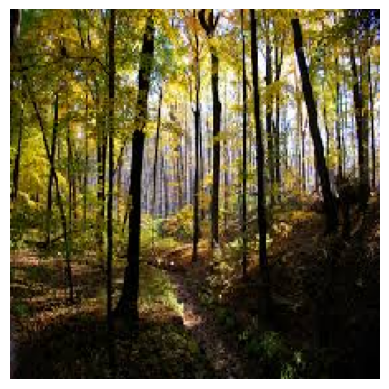


🎯 **Prediction:** forest
📈 **Confidence:** 100.00%

📊 **All probabilities:**
  buildings: 0.00%
  forest: 100.00%
  glacier: 0.00%
  mountain: 0.00%
  sea: 0.00%
  street: 0.00%

Testing: download (2).jpg


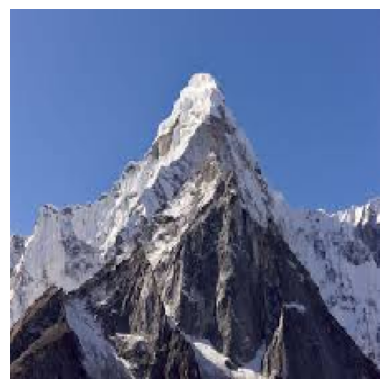


🎯 **Prediction:** mountain
📈 **Confidence:** 44.34%

📊 **All probabilities:**
  buildings: 17.87%
  forest: 1.77%
  glacier: 19.28%
  mountain: 44.34%
  sea: 13.56%
  street: 3.18%

Testing: download (1).jpg


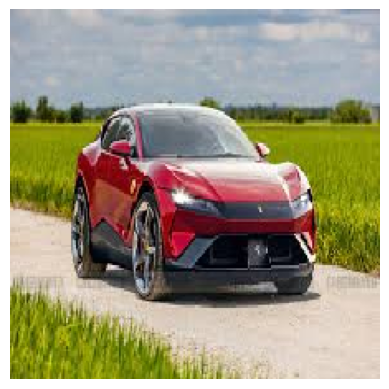


🎯 **Prediction:** street
📈 **Confidence:** 32.38%

📊 **All probabilities:**
  buildings: 15.11%
  forest: 11.44%
  glacier: 7.06%
  mountain: 24.69%
  sea: 9.30%
  street: 32.38%


In [10]:
# CELL 7: LOAD AND TEST MODEL
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load the saved model (use .keras if you changed it)
model = tf.keras.models.load_model("/content/drive/MyDrive/ML_Assignment/scene_classifier_model.h5")
print("✅ Model loaded successfully!")

# Get class names from training data
class_names = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
print("Class names:", class_names)

# Function to test an image
def test_unseen_image(image_path):
    print(f"\n{'='*50}")
    print(f"Testing: {os.path.basename(image_path)}")
    print('='*50)

    # Load and preprocess image
    img = image.load_img(image_path, target_size=(224, 224))

    # Display image
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Convert to array and normalize
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    # Make prediction
    predictions = model.predict(img_array, verbose=0)
    predicted_idx = np.argmax(predictions[0])
    confidence = predictions[0][predicted_idx] * 100

    # Show results
    print(f"\n🎯 **Prediction:** {class_names[predicted_idx]}")
    print(f"📈 **Confidence:** {confidence:.2f}%")

    # Show all class probabilities
    print("\n📊 **All probabilities:**")
    for i, class_name in enumerate(class_names):
        prob = predictions[0][i] * 100
        print(f"  {class_name}: {prob:.2f}%")

    return class_names[predicted_idx]

# CELL 8: TEST MULTIPLE UNSEEN IMAGES
print("\n" + "="*60)
print("TESTING WITH UNSEEN IMAGES FROM LOCALITY/ONLINE")
print("="*60)

# Create test_images folder if it doesn't exist
test_folder = "/content/drive/MyDrive/ML_Assignment/test_images"
os.makedirs(test_folder, exist_ok=True)

# Check what test images you have
print("\n📁 Checking test images folder...")
if os.path.exists(test_folder):
    test_files = [f for f in os.listdir(test_folder) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    if test_files:
        print(f"Found {len(test_files)} test image(s):")
        for f in test_files:
            print(f"  - {f}")
    else:
        print("❌ No test images found. Please upload images to:")
        print(f"   {test_folder}")
        print("\n📸 You can:")
        print("   1. Take photos with your phone and upload")
        print("   2. Download images from Google")
        print("   3. Use these sample images if you want:")
        print("      - A photo of a street/building near you")
        print("      - A mountain/forest photo")
        print("      - A sea/beach photo")

# Test each image
if 'test_files' in locals() and test_files:
    for test_file in test_files:
        test_path = os.path.join(test_folder, test_file)
        test_unseen_image(test_path)
else:
    print("\n⚠️  To complete your assignment, please:")
    print("   1. Create folder: ML_Assignment/test_images/ in Google Drive")
    print("   2. Upload 2-3 photos (buildings, street, forest, etc.)")
    print("   3. Run this cell again")